In [9]:
import numpy as np

from power_demand_analysis import plotting
from power_demand_analysis.load import load_all

plotting.setup()
df = load_all()

[Text(0.5, 0, '時刻'), Text(0, 0.5, '平均需要(万kW)'), Text(0.5, 1.0, '時間帯別の平均電力需要')]

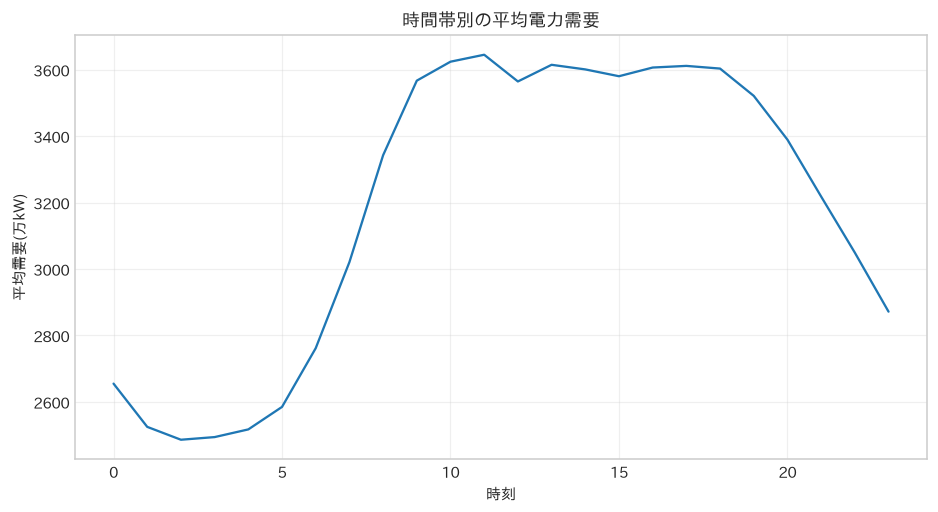

In [10]:
ax = df.groupby(df.index.hour)["demand_10mw"].mean().plot()
ax.set(xlabel="時刻", ylabel="平均需要(万kW)", title="時間帯別の平均電力需要")

[Text(0.5, 0, '時刻'),
 Text(0, 0.5, '平均需要 (万kW)'),
 Text(0.5, 1.0, '時間帯別の平均電力需要（平日 / 土日）')]

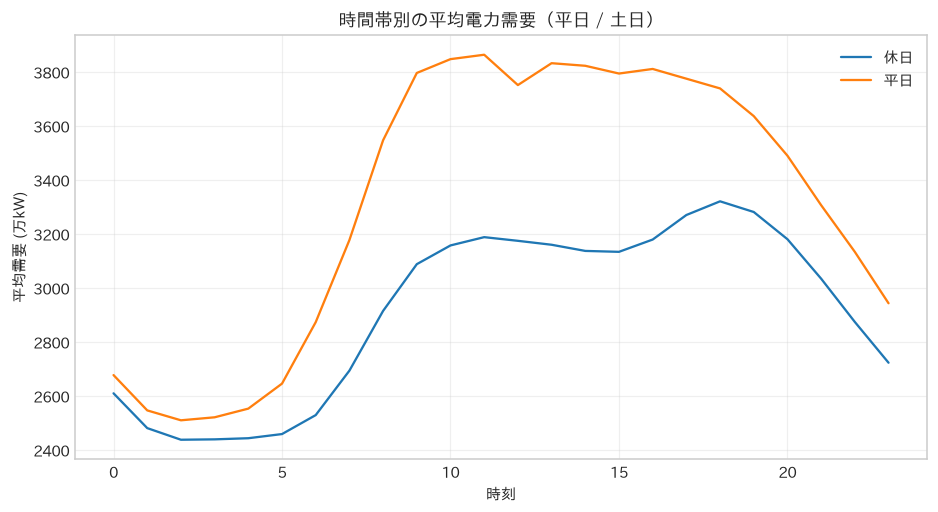

In [21]:
import jpholiday

holiday = np.array([jpholiday.is_holiday(d) for d in df.index.date])

s = np.where((df.index.dayofweek >= 5) | holiday, "休日", "平日")
ax = df.groupby([s, df.index.hour])["demand_10mw"].mean().unstack(0).plot()
ax.set(
    xlabel="時刻",
    ylabel="平均需要 (万kW)",
    title="時間帯別の平均電力需要（平日 / 土日）",
)